### PHONON WORKFLOW

#### download primcell by elements

In [ ]:
import os
import re
import pandas as pd
from pymatgen.ext.matproj import MPRester
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# 替换为您的Materials Project API密钥
api_key = "dhoDCQisv9Yf8ncLsEiaxJgVfTen5vUP"

# 读取Excel文件中的数据
df = pd.read_excel("D:/PHD/alloy anode/material structure/dataset.xlsx")
material_ids = df["Material ID"].tolist()

# 指定保存CIF文件的目标目录
output_directory = "D:/PHD/alloy anode/material structure/CIFs"
# 确保输出目录存在
os.makedirs(output_directory, exist_ok=True)

with MPRester(api_key) as mpr:
    for material_id,i in zip(material_ids,range(7,13)):
        try:
            structure = mpr.get_structure_by_material_id(material_id, conventional_unit_cell=True)
            analyzer = SpacegroupAnalyzer(structure)
            space_group = analyzer.get_space_group_symbol()
            # 替换空间群中的非法字符（如斜杠）
            space_group = re.sub(r'[<>:"/\\|?*]', '_', space_group)
            formula = structure.composition.reduced_formula
            # 构建文件名
            cif_filename = os.path.join(output_directory, f"{i}-{formula}-{material_id}-{space_group}.cif")
            # 保存CIF文件
            structure.to(filename=cif_filename, fmt="cif")
            print(f"Downloaded CIF for {material_id} and saved as {cif_filename}")
        except Exception as e:
            print(f"Error processing {material_id}: {e}")


#### submit phonon calculation

### plot from phonon.out

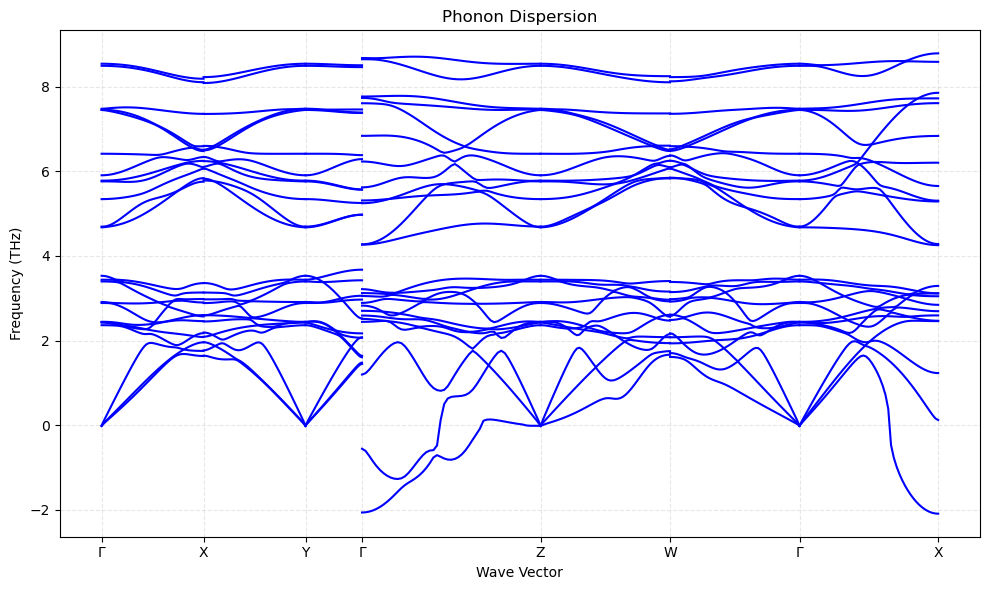

In [195]:
import matplotlib.pyplot as plt
import numpy as np

file_path = "/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/phonon.out"

# 智能数据分段读取
segments = []
current_seg = []
high_sym_points = []

with open(file_path, 'r') as f:
    lines = f.readlines()
    # 读取第二行的注释内容（高对称点坐标）
    high_sym_line = lines[1].strip().split()[1:]
    high_sym_points = list(map(float, high_sym_line))
    
with open(file_path) as f:
    # 跳过前两行注释
    for line in f.readlines()[2:]:
        line = line.strip()
        
        if not line:  # 遇到空行表示分段
            if current_seg:
                segments.append(np.array(current_seg).T)
                current_seg = []
            continue
            
        if line[0].isdigit() or line[0] == '.':  # 判断是否为数据行
            try:
                x, y = map(float, line.split()[:2])
                current_seg.append([x, y])
            except:
                continue

# 处理最后一个分段
if current_seg:
    segments.append(np.array(current_seg).T)

# 绘制图形
plt.figure(figsize=(10, 6))
for seg in segments:
    if seg.size > 0:
        plt.plot(seg[0], seg[1], 'b-', lw=1.5)

plt.xlabel('Wave Vector')
labels = ['Γ','X', 'Y', 'Γ','Z','W','Γ','X']  # 修改为你的实际符号
plt.xticks(high_sym_points, labels)
plt.ylabel('Frequency (THz)')
plt.title('Phonon Dispersion')
plt.grid(alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

### 从POSCAR-unitcell生成配置文件

In [20]:
import numpy as np
import seekpath

# ========== 元素符号到原子序数的映射（覆盖常见元素） ==========
element_to_z = {
    'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'Ne': 10,
    'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15, 'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19,
    'Ca': 20, 'Sc': 21, 'Ti': 22, 'V': 23, 'Cr': 24, 'Mn': 25, 'Fe': 26, 'Co': 27, 'Ni': 28,
    'Cu': 29, 'Zn': 30, 'Ga': 31, 'Ge': 32, 'As': 33, 'Se': 34, 'Br': 35, 'Kr': 36,
    'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40, 'Nb': 41, 'Mo': 42, 'Tc': 43, 'Ru': 44, 'Rh': 45,
    'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50, 'Sb': 51, 'Te': 52, 'I': 53, 'Xe': 54,
    'Cs': 55, 'Ba': 56, 'La': 57, 'Ce': 58, 'Pr': 59, 'Nd': 60, 'Pm': 61, 'Sm': 62, 'Eu': 63,
    'Gd': 64, 'Tb': 65, 'Dy': 66, 'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70, 'Lu': 71, 'Hf': 72,
    'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77, 'Pt': 78, 'Au': 79, 'Hg': 80
}

def parse_poscar(poscar_file):
    """
    解析 VASP POSCAR 文件，返回 seekpath 所需的 cell 字典
    """
    with open(poscar_file, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    # 读取缩放因子和基矢
    scale_factor = float(lines[1])
    lattice = []
    for line in lines[2:5]:
        vec = list(map(float, line.split()))
        lattice.append([scale_factor * x for x in vec])
    
    # 读取元素种类和原子数量
    elements = lines[5].split()
    n_atoms = list(map(int, lines[6].split()))
    
    # 构造原子序数列表
    numbers = []
    for elem, n in zip(elements, n_atoms):
        z = element_to_z.get(elem.capitalize())
        if z is None:
            raise ValueError(f"Unsupported element: {elem}")
        numbers.extend([z] * n)
    
    # 读取原子坐标（假设为分数坐标）
    coord_type = lines[7].lower()
    positions = []
    for line in lines[8:8+sum(n_atoms)]:
        pos = list(map(float, line.split()[:3]))
        positions.append(pos)
    
    # 若为笛卡尔坐标，转换为分数坐标
    if coord_type.startswith('c'):
        positions = np.dot(positions, np.linalg.inv(lattice)).tolist()
    
    return {
        'lattice': lattice,
        'positions': positions,
        'numbers': numbers
    }

def generate_band_conf(poscar_file, output_file):
    """
    主函数：读取 POSCAR -> 生成 k 路径 -> 写入 band.conf
    """
    # Step 1: 解析 POSCAR
    cell = parse_poscar(poscar_file)
    
    # Step 2: 将字典转换为 seekpath 所需的元组结构 (lattice, positions, numbers)
    seekpath_input = (
        np.array(cell['lattice']),
        np.array(cell['positions']),
        np.array(cell['numbers'])
    )
    
    # Step 3: 使用 seekpath 获取高对称路径
    path_data = seekpath.get_path(seekpath_input)
    
    # Step 4: 构造 path 字典
    path = {
        'path': path_data['path'],
        'point_coords': path_data['point_coords']
    }
    
    # Step 5: 生成 Phonopy 配置文件
    elements = open(poscar_file).readlines()[5].split()
    atom_name = "-".join(elements)
    Get_Bandconf(path, atom_name=atom_name, fout=output_file)

# ========== 您提供的配置生成函数 ==========
def Get_Bandconf(path, atom_name, fout, nrep=2):
    """
    生成Phonopy配置文件
    参数：
        path: k点路径数据
        atom_name: 元素名称
        nrep: 超胞扩展倍数
        ptype: 势函数类型
        fout: 输出文件名
    """
    
    # k点标签格式化处理
    kpoints = 'BAND_LABELS = '
    coord = 'BAND = '
    for i, pi in enumerate(path['path']):
        # 特殊符号处理（Γ点）
        label = '$\Gamma$'if pi[0] == 'GAMMA'else pi[0]
        kpoints += f"{label} "
        # 坐标转换
        coord += ' '.join(map(str, path['point_coords'][pi[0]])) + ' '
    
    # 配置文件写入
    with open(fout, 'w') as fo:
        config = f"ATOM_NAME = {atom_name}\nDIM = {nrep} {nrep} {nrep}\n"
        config += f"{kpoints}\n{coord}\nFORCE_CONSTANTS = READ\n"
        fo.write(config)

if __name__ == '__main__':
    generate_band_conf(poscar_file='/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/try/POSCAR', output_file='/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/try/band.conf')

### mattersim predicted phonon

#### single calculation

In [20]:
#%% md
### 预测能量并排序
#%%
import torch
from ase.build import bulk
from ase.units import GPa
from ase.io import read
from mattersim.forcefield import MatterSimCalculator
import time
import os
# 设置设备为CUDA（GPU）或CPU
# 定义文件夹路径
structure = read("/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/opt/split_01_gen_1/split_01_gen_1.cif")
structure.calc = MatterSimCalculator(load_path="/lustre/home/acct-umjzhh/umjzhh/suchen/software/LGM-SCF.pth")
potential_energy = structure.get_potential_energy()
print(potential_energy)


2025-04-23 21:51:11.144 | INFO     | mattersim.forcefield.potential:from_checkpoint:891 - Loading the model from /lustre/home/acct-umjzhh/umjzhh/suchen/software/LGM-SCF.pth


-19.386995


In [12]:
structure = read("/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/opt/1-LiGa-mp-1307/OUTCAR")
structure.get_potential_energy()

-10.9036422

In [13]:
static_energy_per_atom

-2.4247729778289795

2025-04-23 21:37:15.094 | INFO     | mattersim.forcefield.potential:from_checkpoint:891 - Loading the model from /lustre/home/acct-umjzhh/umjzhh/suchen/software/LGM-AIMD-PRI.pth


自动生成的扩胞矩阵: diag([3, 3, 2])
Supercell matrix for 2nd force constants : 
[[3 0 0]
 [0 3 0]
 [0 0 2]]


Inferring forces for displaced atoms and computing fcs ...


100%|██████████| 48/48 [00:08<00:00,  5.98it/s]
/lustre/home/acct-umjzhh/umjzhh/.conda/envs/py3.9/lib/python3.9/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/lustre/home/acct-umjzhh/umjzhh/.conda/envs/py3.9/lib/python3.9/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/lustre/home/acct-umjzhh/umjzhh/.conda/envs/py3.9/lib/python3.9/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/lustre/home/acct-umjzhh/umjzhh/.conda/envs/py3.9/lib/python3.9/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['number']) is

Max drift of force constants: -0.000400 (zz) 0.000015 (yz)
Max drift after symmetrization by translation: -0.000000 (xx) -0.000000 (xx)
Qpoints mesh for Brillouin Zone integration : [9 9 6]
Dispersion relations using phonopy for LiMg3Ga4 ...

Warning! Imaginary frequencies found!

300K自由能: -2.460 eV/atom


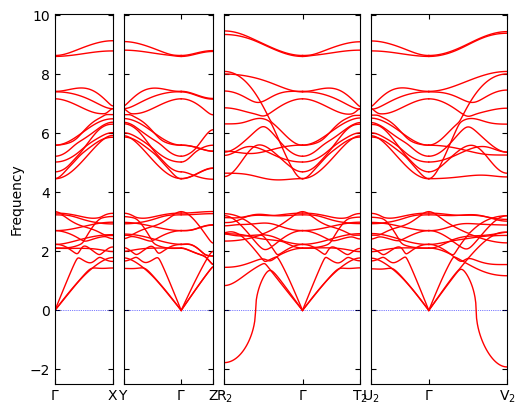

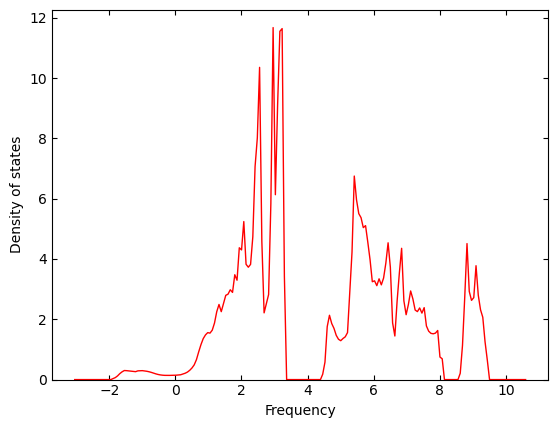

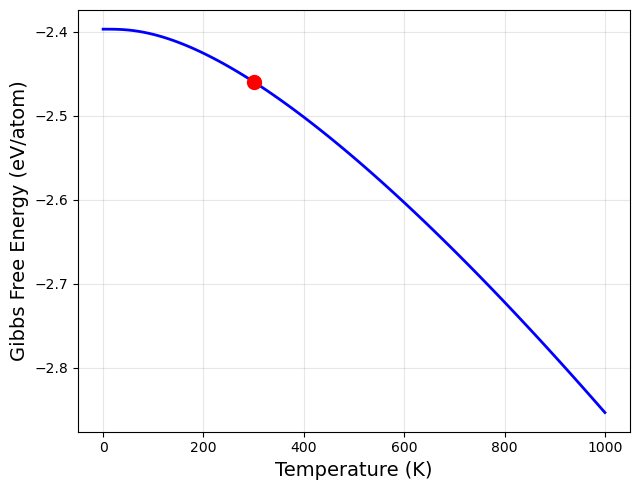

In [3]:
import numpy as np
import yaml
import matplotlib.pyplot as plt
from ase.io import read
from mattersim.forcefield.potential import MatterSimCalculator
from mattersim.applications.phonon import PhononWorkflow

# 初始化晶体结构
structure = read("/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/opt/split_01_gen_1/POSCAR")
structure.set_pbc(True)
n_atoms = structure.get_global_number_of_atoms()

# 自动计算扩胞参数
cell = structure.cell
# 计算各晶格矢量的长度
a_length = np.linalg.norm(cell[0])
b_length = np.linalg.norm(cell[1])
c_length = np.linalg.norm(cell[2])
# 计算满足最小10Å的扩胞倍数
factors = [
    int(np.ceil(10 / a_length)),
    int(np.ceil(10 / b_length)),
    int(np.ceil(10 / c_length))
]
supercell_matrix = np.diag(factors)
print(f"自动生成的扩胞矩阵: diag({factors})")

# 加载MatterSim势函数
calculator = MatterSimCalculator(
    load_path="/lustre/home/acct-umjzhh/umjzhh/suchen/software/LGM-AIMD-PRI.pth",
    device="cpu",
    compute_stress=True
)
structure.calc = calculator

# 计算静态能量
static_energy = structure.get_potential_energy()
static_energy_per_atom = static_energy / n_atoms

# 声子谱计算
ph = PhononWorkflow(
    atoms=structure,
    find_prim=False,
    amplitude=0.01,
    work_dir="./result",
    supercell_matrix= supercell_matrix )
has_imag, phonons = ph.run()

# 热力学性质计算
phonons.run_thermal_properties(t_min=0, t_max=1000, t_step=10)  # 加密温度采样
thermal = phonons.get_thermal_properties_dict()

# 从运行得到的结果提取正确的natom
phonons.thermal_properties.write_yaml(filename='./result/thermal_properties.yaml')
# 读取YAML文件
with open('./result/thermal_properties.yaml', 'r') as f:
    data = yaml.safe_load(f)
# 提取 natom 值
natom_prime = data['natom']

# 自由能计算
temps = thermal['temperatures']
vib_free = thermal['free_energy']*0.0103643/ natom_prime  # 转换为每原子值
total_free = static_energy_per_atom + vib_free

# 获取300K最近邻数据
idx_300K = np.abs(temps - 300).argmin()
free_300K = total_free[idx_300K]

print(f"\n300K自由能: {free_300K:.3f} eV/atom")

# 绘制曲线
plt.figure(figsize=(6.5,5))
plt.plot(temps, total_free, 'b-', label="Gibbs Free Energy",lw=2)
plt.scatter(300, free_300K, s=100, zorder=3,color='red')
plt.xlabel("Temperature (K)", fontsize=14)
plt.ylabel("Gibbs Free Energy (eV/atom)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### batch phonon

2025-04-17 17:54:50.694 | INFO     | mattersim.forcefield.potential:from_checkpoint:891 - Loading the model from /lustre/home/acct-umjzhh/umjzhh/suchen/software/LGM-SCF.pth


自动生成的扩胞矩阵: diag([3, 3, 3])
Supercell matrix for 2nd force constants : 
[[3 0 0]
 [0 3 0]
 [0 0 3]]


Inferring forces for displaced atoms and computing fcs ...


100%|██████████| 2/2 [00:00<00:00,  6.36it/s]


Max drift of force constants: 0.000086 (yy) 0.000001 (yy)
Max drift after symmetrization by translation: 0.000000 (yy) 0.000000 (yy)
Qpoints mesh for Brillouin Zone integration : [18 18 18]
Dispersion relations using phonopy for Li2Ga2 ...

Warning! Imaginary frequencies found!

300K自由能: -2.730 eV/atom
自动生成的扩胞矩阵: diag([3, 3, 2])
Supercell matrix for 2nd force constants : 
[[3 0 0]
 [0 3 0]
 [0 0 2]]


Inferring forces for displaced atoms and computing fcs ...


100%|██████████| 48/48 [00:09<00:00,  5.09it/s]


Max drift of force constants: 0.001431 (zz) 0.000011 (xz)
Max drift after symmetrization by translation: 0.000000 (xx) 0.000000 (xx)
Qpoints mesh for Brillouin Zone integration : [9 9 6]
Dispersion relations using phonopy for LiMg3Ga4 ...

Warning! Imaginary frequencies found!

300K自由能: -2.462 eV/atom


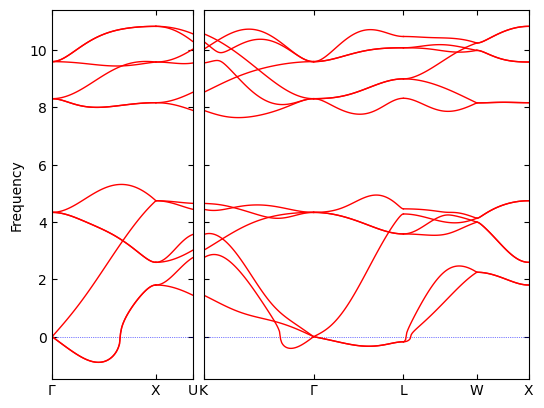

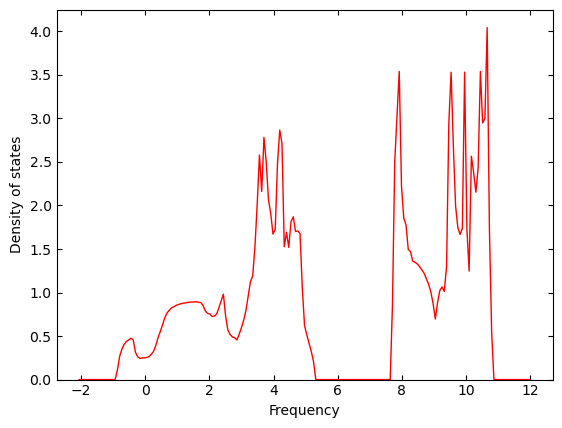

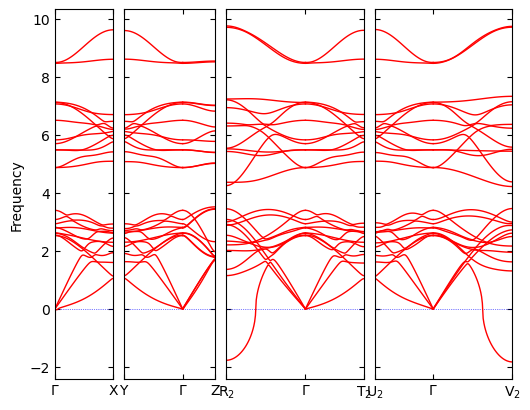

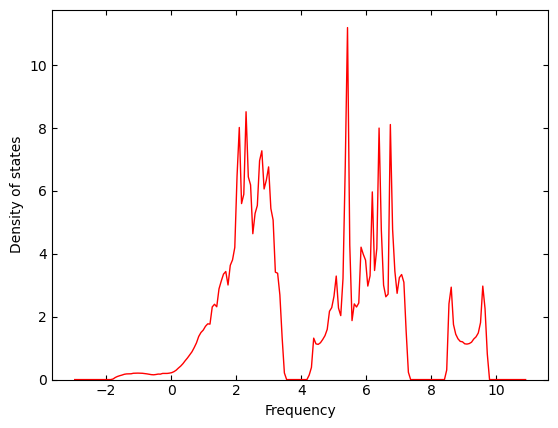

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from mattersim.forcefield.potential import MatterSimCalculator
from mattersim.applications.phonon import PhononWorkflow

# 加载MatterSim势函数
calculator = MatterSimCalculator(
    load_path="/lustre/home/acct-umjzhh/umjzhh/suchen/software/LGM-SCF.pth",
    device="cpu",
    compute_stress=True
)

base_dir = "/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/opt/"
for f in os.listdir(base_dir):
    # 初始化晶体结构
    target_dir = os.path.join(base_dir, f)
    structure = read(os.path.join(target_dir, "POSCAR"))
    structure.set_pbc(True)
    n_atoms = structure.get_global_number_of_atoms()
    structure.calc = calculator
    # 自动计算扩胞参数
    cell = structure.cell
    # 计算各晶格矢量的长度
    a_length = np.linalg.norm(cell[0])
    b_length = np.linalg.norm(cell[1])
    c_length = np.linalg.norm(cell[2])
    # 计算满足最小10Å的扩胞倍数
    factors = [
        int(np.ceil(10 / a_length)),
        int(np.ceil(10 / b_length)),
        int(np.ceil(10 / c_length))
    ]
    supercell_matrix = np.diag(factors)
    print(f"自动生成的扩胞矩阵: diag({factors})")
    
    # 计算静态能量
    static_energy = structure.get_potential_energy()
    static_energy_per_atom = static_energy / n_atoms

    # 声子谱计算
    ph = PhononWorkflow(
        atoms=structure,
        find_prim=False,
        amplitude=0.01,
        work_dir="./result",
        supercell_matrix=supercell_matrix)
    has_imag, phonons = ph.run()

    # 热力学性质计算
    phonons.run_thermal_properties(t_min=0, t_max=1000, t_step=10)  # 加密温度采样
    thermal = phonons.get_thermal_properties_dict()

    # 从运行得到的结果提取正确的natom
    phonons.thermal_properties.write_yaml(filename='./result/thermal_properties.yaml')
    # 读取YAML文件
    with open('./result/thermal_properties.yaml', 'r') as f:
        data = yaml.safe_load(f)
    # 提取 natom 值
    natom_prime = data['natom']

    # 自由能计算
    temps = thermal['temperatures']
    vib_free = thermal['free_energy']*0.0103643/ natom_prime  # 转换为每原子值
    total_free = static_energy_per_atom + vib_free

    # 获取300K最近邻数据
    idx_300K = np.abs(temps - 300).argmin()
    free_300K = total_free[idx_300K]

    print(f"\n300K自由能: {free_300K:.3f} eV/atom")

# # 绘制曲线
# plt.figure(figsize=(6.5,5))
# plt.plot(temps, total_free, 'b-', label="Gibbs Free Energy",lw=2)
# plt.scatter(300, free_300K, s=100, zorder=3,color='red')
# plt.xlabel("Temperature (K)", fontsize=14)
# plt.ylabel("Gibbs Free Energy (eV/atom)", fontsize=14)
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

In [183]:
static_energy

-19.386995

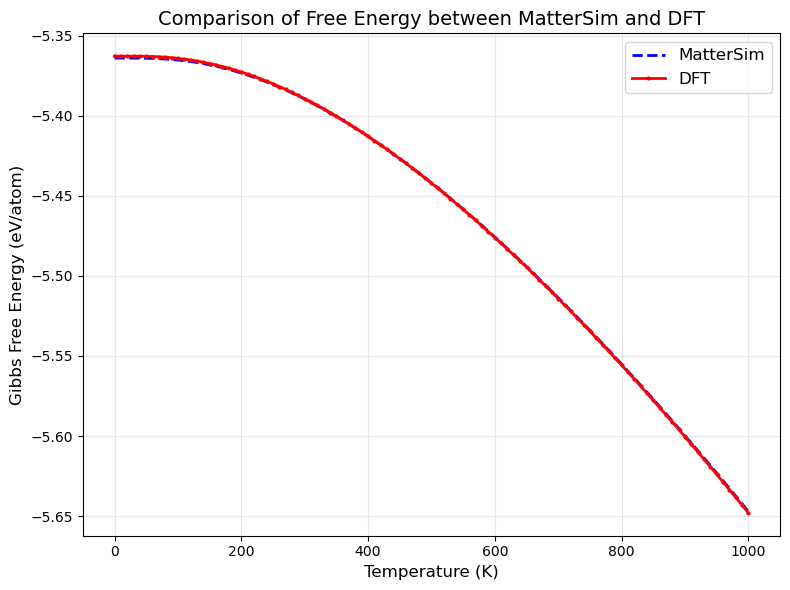

In [80]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取 MatterSim 计算结果（沿用之前的代码）
with open('./result/thermal_properties.yaml', 'r') as f:
    mattersim_data = yaml.safe_load(f)

mattersim_temperatures = np.array([tp['temperature'] for tp in mattersim_data['thermal_properties']])
#mattersim_free_energy = np.array([static_energy_per_atom + (tp['free_energy']* 0.0103643 /mattersim_data['natom']) for tp in mattersim_data['thermal_properties']]) 
mattersim_free_energy = np.array([-5.4238 + (tp['free_energy']* 0.0103643 /mattersim_data['natom']) for tp in mattersim_data['thermal_properties']]) 
# 2. 读取 DFT 计算结果
with open('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/try/thermal_properties.yaml', 'r') as f:  # 替换为你的DFT文件路径
    dft_data = yaml.safe_load(f)

# 提取 DFT 数据
natom_prime = dft_data['natom']
dft_temperatures = np.array([tp['temperature'] for tp in dft_data['thermal_properties']])
dft_free_energy = np.array([-5.4238 + (tp['free_energy'] * 0.0103643 / natom_prime) for tp in dft_data['thermal_properties']])

# 3. 绘制对比图
plt.figure(figsize=(8, 6))

# MatterSim 曲线
plt.plot(mattersim_temperatures, mattersim_free_energy, 
         label='MatterSim', color='blue', linewidth=2, linestyle='--')

# DFT 曲线
plt.plot(dft_temperatures, dft_free_energy, 
         label='DFT', color='red', linewidth=2, marker='o', markersize=2)

# 标注 300 K 点
free_300K_mattersim = mattersim_free_energy[np.where(mattersim_temperatures == 300)[0][0]]
free_300K_dft = dft_free_energy[np.where(dft_temperatures == 300)[0][0]]

# plt.scatter(300, free_300K_mattersim, s=80, color='blue', zorder=3)
# plt.scatter(300, free_300K_dft, s=80, color='red', zorder=3)

# 图表装饰
plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Gibbs Free Energy (eV/atom)", fontsize=12)
plt.title("Comparison of Free Energy between MatterSim and DFT", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

# 保存或显示
# plt.savefig('free_energy_comparison.png', dpi=300)
plt.show()

### DFT和mattersim声子谱对比

In [17]:
free_300K_mattersim

-2.460829988298545

In [10]:
free_300K_dft

-2.4585453629813534

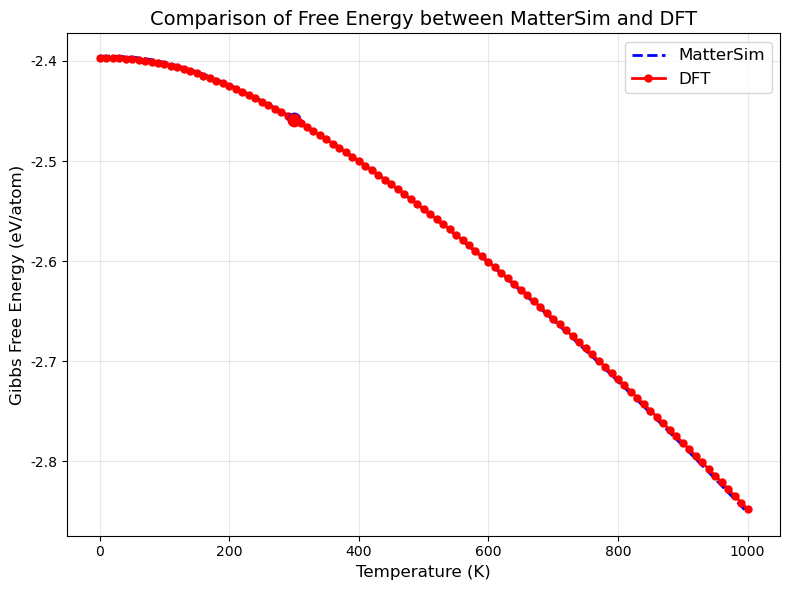

In [21]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取 MatterSim 计算结果（沿用之前的代码）
with open('./result/thermal_properties.yaml', 'r') as f:
    mattersim_data = yaml.safe_load(f)

    mattersim_temperatures = np.array([tp['temperature'] for tp in mattersim_data['thermal_properties']])
    mattersim_free_energy = np.array([-2.423+ (tp['free_energy'] * 0.0103643 / natom_prime) for tp in mattersim_data['thermal_properties']])

# 2. 读取 DFT 计算结果
with open('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/thermal_properties.yaml', 'r') as f:  # 替换为你的DFT文件路径
    dft_data = yaml.safe_load(f)

    # 提取 DFT 数据
    natom_prime = dft_data['natom']
    dft_temperatures = np.array([tp['temperature'] for tp in dft_data['thermal_properties']])
    dft_free_energy = np.array([-2.425 + (tp['free_energy'] * 0.0103643 / natom_prime) for tp in dft_data['thermal_properties']])

# 3. 绘制对比图
plt.figure(figsize=(8, 6))

# MatterSim 曲线
plt.plot(mattersim_temperatures, mattersim_free_energy, 
         label='MatterSim', color='blue', linewidth=2, linestyle='--')

# DFT 曲线
plt.plot(dft_temperatures, dft_free_energy, 
         label='DFT', color='red', linewidth=2, marker='o', markersize=5)

# 标注 300 K 点
free_300K_mattersim = mattersim_free_energy[np.where(mattersim_temperatures == 300)[0][0]]
free_300K_dft = dft_free_energy[np.where(dft_temperatures == 300)[0][0]]

plt.scatter(300, free_300K_mattersim, s=80, color='blue', zorder=3)
plt.scatter(300, free_300K_dft, s=80, color='red', zorder=3)

# 图表装饰
plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Gibbs Free Energy (eV/atom)", fontsize=12)
plt.title("Comparison of Free Energy between MatterSim and DFT", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

# 保存或显示
plt.savefig('free_energy_comparison.png', dpi=300)
plt.show()

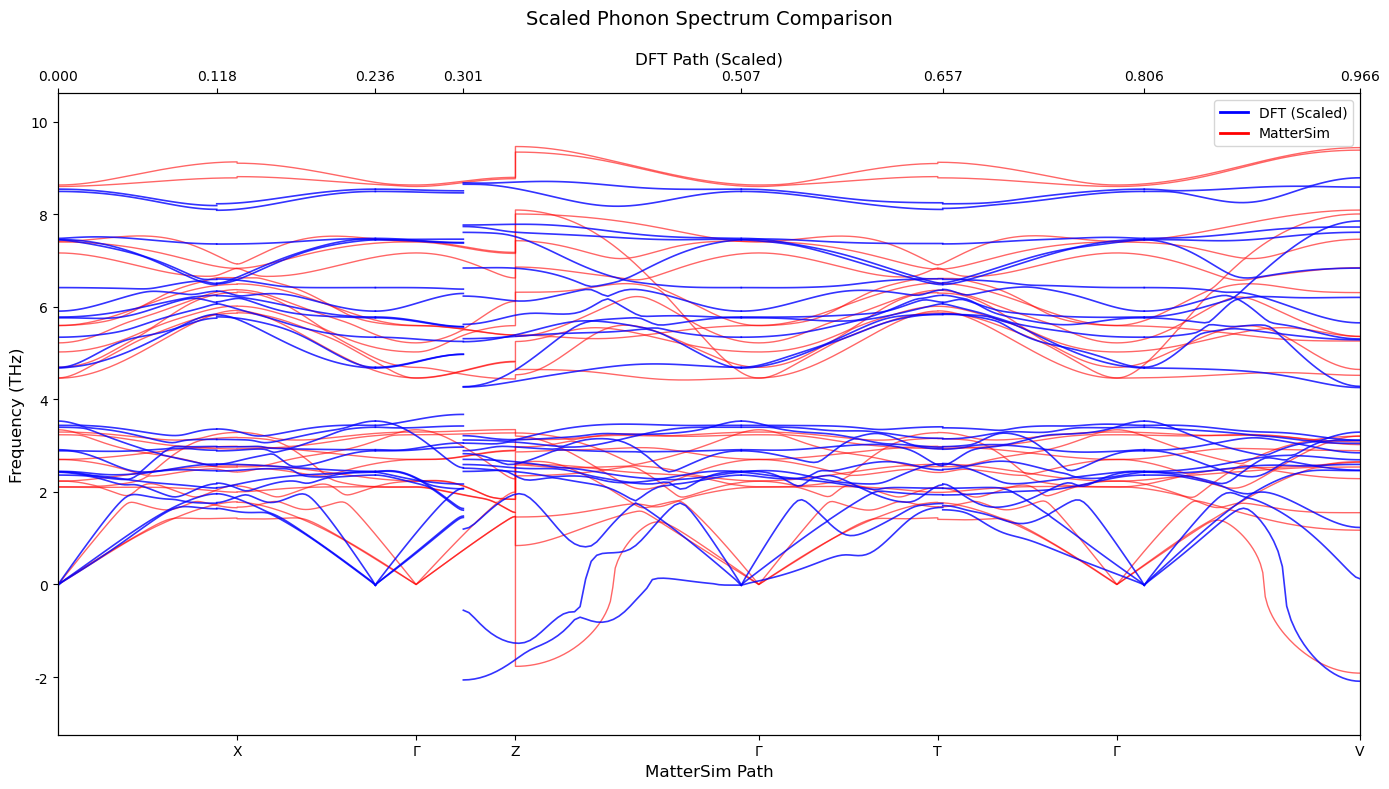

In [8]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

def read_dft_data(dft_path):
    """读取DFT数据并保留原始范围信息"""
    segments = []
    current_seg = []
    dft_ticks = []

    with open(dft_path, 'r') as f:
        lines = f.readlines()
        dft_ticks = list(map(float, lines[1].strip().split()[1:]))
        
    with open(dft_path) as f:
        for line in f.readlines()[2:]:
            line = line.strip()
            if not line:
                if current_seg:
                    segments.append(np.array(current_seg).T)
                    current_seg = []
                continue
                
            if line[0].isdigit() or line[0] == '.':
                try:
                    x, y = map(float, line.split()[:2])
                    current_seg.append([x, y])
                except:
                    continue

    if current_seg:
        segments.append(np.array(current_seg).T)
    
    # 计算原始最大x值
    dft_max_x = max([seg[0][-1] for seg in segments if seg.size > 0])
    
    return segments, dft_ticks, dft_max_x

def read_mattersim_data(yaml_path):
    """读取完整的MatterSim数据（修正24能带版本）"""
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    
    phonon_data = data['phonon']
    
    # 确定能带数量（根据第一个数据点判断）
    n_bands = len(phonon_data[0]['band']) if phonon_data else 0
    
    # 初始化能带容器
    bands = [[] for _ in range(n_bands)]
    for p in phonon_data:
        for i in range(n_bands):
            # 直接读取每个频带的频率值
            bands[i].append(p['band'][i]['frequency'])
    
    # 计算高对称点位置
    distances = [p['distance'] for p in phonon_data]
    
    # 生成高对称点标签
    segments = data['segment_nqpoint']
    tick_indices = []
    current_index = 0
    for s in segments:
        current_index += s
        tick_indices.append(current_index-1)
    
    ms_ticks = [phonon_data[i]['distance'] for i in tick_indices if i < len(phonon_data)]
    
    # 处理希腊字母标签
    label_mapping = {
        'Gamma': 'Γ',
        'X': 'X',
        'Y': 'Y',
        'Z': 'Z',
        'R_2': 'R',
        'T_2': 'T',
        'U_2': 'U',
        'V_2': 'V'
    }
    ms_labels = []
    for seg in data['labels']:
        raw_label = seg[1].replace('$','').replace('\\mathrm{','').replace('}','')
        for key in label_mapping:
            if key in raw_label:
                ms_labels.append(label_mapping[key])
                break
        else:
            ms_labels.append(raw_label)
    
    return distances, bands, ms_ticks, ms_labels[:len(ms_ticks)]


def plot_dual_axis_comparison(dft_data, ms_data):
    """动态缩放DFT数据对齐MatterSim范围"""
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # ===== 准备数据 =====
    ms_distances, ms_bands, ms_ticks, ms_labels = ms_data
    dft_segments, dft_ticks, dft_original_max = dft_data
    
    # 计算缩放比例
    ms_max_x = max(ms_distances)
    scale_factor = ms_max_x / dft_original_max
    
    # ===== 绘制MatterSim数据 =====
    for band in ms_bands:
        ax.plot(ms_distances, band, 'r-', lw=1.0, alpha=0.6)
    
    # ===== 缩放并绘制DFT数据 =====
    ax2 = ax.twiny()
    scaled_dft_ticks = [x * scale_factor for x in dft_ticks]
    
    for seg in dft_segments:
        if seg.size > 0:
            scaled_x = seg[0] * scale_factor  # 关键缩放步骤
            ax2.plot(scaled_x, seg[1], 'b-', lw=1.2, alpha=0.8)
    
    # ===== 坐标轴设置 =====
    # 设置统一范围
    ax.set_xlim(0, ms_max_x)
    ax2.set_xlim(0, ms_max_x)
    
    # MatterSim坐标轴
    ax.set_xlabel('MatterSim Path', fontsize=12)
    ax.set_xticks(ms_ticks)
    ax.set_xticklabels(ms_labels)
    ax.set_ylabel('Frequency (THz)', fontsize=12)
    
    # DFT坐标轴
    ax2.set_xticks(scaled_dft_ticks)
    ax2.set_xticklabels([f'{x:.3f}' for x in dft_ticks])  # 显示原始刻度值
    ax2.set_xlabel('DFT Path (Scaled)', fontsize=12)
    
    # ===== 自动调整纵坐标 =====
    all_freq = [f for band in ms_bands for f in band]
    for seg in dft_segments:
        if seg.size > 0:
            all_freq.extend(seg[1].flatten())
    
    y_min = min(all_freq)
    y_max = max(all_freq)
    ax.set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
    
    # ===== 图例和标题 =====
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', lw=2, label='DFT (Scaled)'),
        Line2D([0], [0], color='red', lw=2, label='MatterSim')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    plt.title('Scaled Phonon Spectrum Comparison', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

# 使用方式（注意read_dft_data返回三个值）
if __name__ == "__main__":
    dft_segments, dft_ticks, dft_max = read_dft_data("/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/phonon.out")
    ms_distances, ms_bands, ms_ticks, ms_labels = read_mattersim_data("./result/band.yaml")
    plot_dual_axis_comparison(
        dft_data=(dft_segments, dft_ticks, dft_max),
        ms_data=(ms_distances, ms_bands, ms_ticks, ms_labels)
    )